# Taak 2 — Lego Minifigs
## Multilabel classificatie op basis van `themes`

In deze notebook formuleren we de opdracht als een multilabel image classification probleem.

In plaats van precies één categorie te voorspellen, proberen we hier meerdere mogelijke `themes` per minifig te voorspellen.
Dat betekent dat één afbeelding tegelijk meerdere geldige labels kan hebben.

We bouwen de pipeline opnieuw op vanaf de metadata, maar hergebruiken waar mogelijk dezelfde algemene structuur als in het multiclass-experiment.
De belangrijkste verschillen zullen later zitten in:
- de targetconstructie
- de label encoding
- de train/validation/test split
- de loss function
- de evaluatiemetrics

Volgens de cursus is de definitie van de target een cruciale ontwerpbeslissing, en zijn meerdere probleemformuleringen mogelijk. Voor deze versie kiezen we expliciet voor een multilabel setup op basis van de `themes`-metadata. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

In [ ]:
import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

JSON_PATH = "data/minifigs.json"
IMAGE_ROOT = "data/images"

with open(JSON_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

# Basis cleaning
df = df.dropna(subset=["img_local_path"]).copy()

def build_full_path(img_local_path, image_root=IMAGE_ROOT):
    filename = os.path.basename(img_local_path)
    return os.path.join(image_root, filename)

df["full_path"] = df["img_local_path"].apply(build_full_path)
df["file_exists"] = df["full_path"].apply(os.path.exists)
df = df[df["file_exists"]].copy()

print("\nNumber of rows after cleaning and file check:", len(df))

# Eerste blik op themes
print("\nExample of themes column:")
print(df["themes"].head())

# Device en transforms al klaarzetten
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Aantal rijen: 17362
Aantal kolommen: 15

Kolommen:
['id', 'name', 'link', 'year', 'img_url', 'minifig_number', 'category', 'subcategory', 'year_released', 'set_id', 'current_value_new', 'current_value_used', 'character_name', 'img_local_path', 'themes']

Aantal rijen na cleaning en file check: 17361

Voorbeeld van themes-kolom:
0                                   [LEGOLAND]
1    [Basic, LEGOLAND, Universal Building Set]
2                                   [LEGOLAND]
3                                   [LEGOLAND]
4                                   [LEGOLAND]
Name: themes, dtype: object

Device: cpu


## Deel 1: `themes` analyseren en de multilabel-target definiëren

In dit deel analyseren we de `themes`-kolom en bepalen we welke labels we in het multilabel-experiment willen behouden.

Omdat multilabel-classification moeilijker is dan multiclass-classification, is het niet verstandig om alle mogelijke themes blind te gebruiken.
Zeer zeldzame labels zouden tot instabiele training en onbetrouwbare evaluatie leiden.

Daarom doen we het volgende:
1. alle themes over alle minifigs verzamelen
2. hun frequentie tellen
3. alleen themes behouden die vaak genoeg voorkomen
4. later elke minifig omzetten naar een multi-hot vector over die behouden themes

Dit is in lijn met de cursus, waar targetdefinitie en het eventueel reduceren of herformuleren van groepen expliciet deel uitmaken van een correcte machine-learning pipeline. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

Aantal unieke themes: 144

Top 30 meest voorkomende themes:
City                       2001
Star Wars                  1477
Ninjago                     929
Friends                     877
Duplo                       836
Collectable Minifigures     782
Marvel Super Heroes         703
Town                        700
Harry Potter                637
Castle                      459
Education                   454
Disney                      387
DC Comics Super Heroes      308
Icons                       294
Ideas                       279
BrickLink                   270
Promotional                 258
Dacta                       253
Minecraft                   251
Sports                      234
Super Mario                 229
Seasonal                    227
Gear                        200
Monkie Kid                  182
Space                       172
Creator                     166
Legends of Chima            152
Nexo Knights                148
Pirates                     147
Speed Champi

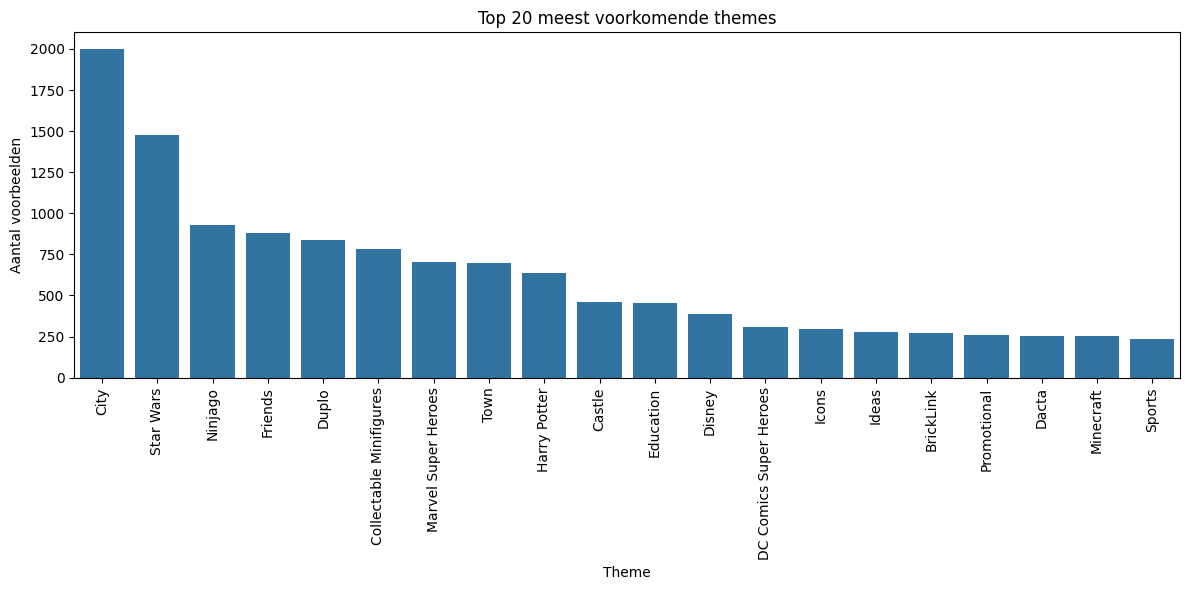


Geselecteerde themes (minstens 50 voorbeelden):
['City', 'Star Wars', 'Ninjago', 'Friends', 'Duplo', 'Collectable Minifigures', 'Marvel Super Heroes', 'Town', 'Harry Potter', 'Castle', 'Education', 'Disney', 'DC Comics Super Heroes', 'Icons', 'Ideas', 'BrickLink', 'Promotional', 'Dacta', 'Minecraft', 'Sports', 'Super Mario', 'Seasonal', 'Gear', 'Monkie Kid', 'Space', 'Creator', 'Legends of Chima', 'Nexo Knights', 'Pirates', 'Speed Champions', 'Creator Expert', 'Juniors', 'Miscellaneous', 'Jurassic World', 'Trains', 'Games', 'Belville', 'Dreamzzz', 'Advanced models', 'The LEGO Batman Movie', 'The LEGO Ninjago Movie', 'Fabuland', 'The LEGO Movie 2', 'Explore', 'Racers', 'The LEGO Movie', 'Hidden Side', 'Dimensions', 'The Hobbit', 'Elves', 'Basic', 'Indiana Jones', 'Cars', 'Teenage Mutant Ninja Turtles', 'Adventurers']

Aantal geselecteerde themes: 55

Aantal rijen vóór multilabel-filter: 17361
Aantal rijen na multilabel-filter: 15860
Percentage behouden: 91.35%

Voorbeeld van originele 

In [ ]:
# Zorg dat themes altijd een Python-lijst is
def ensure_list(x):
    if isinstance(x, list):
        return x
    return []

df["themes_list"] = df["themes"].apply(ensure_list)

# Alle themes flatten
all_themes = [theme for theme_list in df["themes_list"] for theme in theme_list]
theme_counts = pd.Series(all_themes).value_counts()

print("Number of unique themes:", len(theme_counts))
print("\nTop 30 most common themes:")
print(theme_counts.head(30))

# Beschrijvende statistiek
print("\nDescriptive statistics of theme frequencies:")
print(theme_counts.describe())

# Drempels bekijken
thresholds = [5, 10, 20, 50, 100]
print()
for t in thresholds:
    n_themes = (theme_counts >= t).sum()
    print(f"Number of themes with at least {t} examples: {n_themes}")

# Visualisatie van de meest voorkomende themes
plt.figure(figsize=(12, 6))
sns.barplot(x=theme_counts.index[:20], y=theme_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 most common themes")
plt.xlabel("Theme")
plt.ylabel("Number of examples")
plt.tight_layout()
plt.show()

# Definitieve shortlist
MIN_SAMPLES_PER_THEME = 50
selected_themes = theme_counts[theme_counts >= MIN_SAMPLES_PER_THEME].index.tolist()

print("\nSelected themes (at least 50 examples):")
print(selected_themes)

print("\nNumber of selected themes:", len(selected_themes))

# Alleen minifigs behouden die minstens één geselecteerd theme hebben
df["selected_themes"] = df["themes_list"].apply(
    lambda lst: [theme for theme in lst if theme in selected_themes]
)

df_multi = df[df["selected_themes"].apply(len) > 0].copy()

print("\nNumber of rows before multilabel filter:", len(df))
print("Number of rows after multilabel filter:", len(df_multi))
print(f"Percentage kept: {100 * len(df_multi) / len(df):.2f}%")

# Voorbeeldcontrole
print("\nExample of original themes and selected themes:")
print(df_multi[["themes_list", "selected_themes"]].head(10))

## Deel 2: multi-hot encoding van de multilabel-target

In dit deel zetten we de geselecteerde `themes` om naar een multilabel-targetvector.

Voor elk behouden theme voorzien we één outputpositie.
Een minifig krijgt op die positie:
- `1` als het theme aanwezig is
- `0` als het theme afwezig is

Het resultaat is dus geen enkel integer label, maar een multi-hot vector per afbeelding.
Dat is de standaard representatie voor multilabel classification.

Aantal multilabel-targets: 55

Voorbeeld mapping:
[('City', 0), ('Star Wars', 1), ('Ninjago', 2), ('Friends', 3), ('Duplo', 4), ('Collectable Minifigures', 5), ('Marvel Super Heroes', 6), ('Town', 7), ('Harry Potter', 8), ('Castle', 9), ('Education', 10), ('Disney', 11), ('DC Comics Super Heroes', 12), ('Icons', 13), ('Ideas', 14)]

Voorbeeld van geselecteerde themes + targetvector:
Selected themes: ['Basic']
Target vector sum: 1
Target vector shape: (55,)
--------------------------------------------------
Selected themes: ['Basic']
Target vector sum: 1
Target vector shape: (55,)
--------------------------------------------------
Selected themes: ['Trains']
Target vector sum: 1
Target vector shape: (55,)
--------------------------------------------------
Selected themes: ['Basic', 'Trains']
Target vector sum: 2
Target vector shape: (55,)
--------------------------------------------------
Selected themes: ['Trains']
Target vector sum: 1
Target vector shape: (55,)
-----------------------

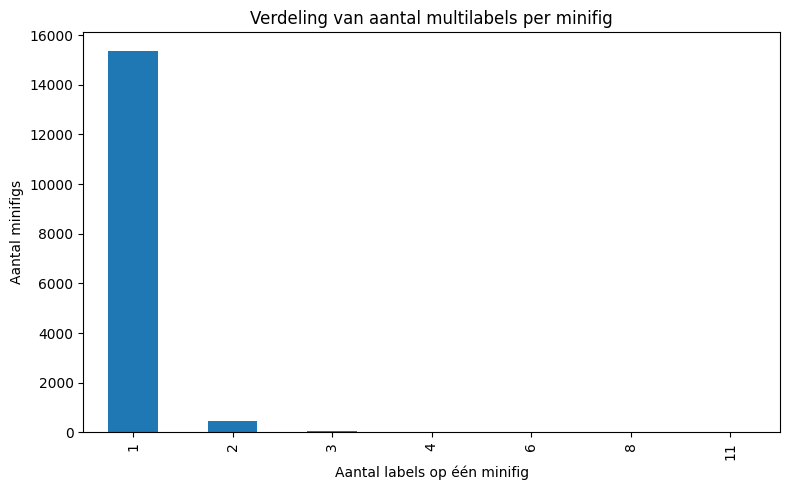

In [ ]:
# Mapping tussen themes en indices
theme_to_idx = {theme: idx for idx, theme in enumerate(selected_themes)}
idx_to_theme = {idx: theme for theme, idx in theme_to_idx.items()}

print("Number of multilabel targets:", len(selected_themes))
print("\nExample mapping:")
print(list(theme_to_idx.items())[:15])

# Functie om multi-hot vector te maken
def make_multihot(theme_list, theme_to_idx):
    vector = np.zeros(len(theme_to_idx), dtype=np.float32)
    for theme in theme_list:
        if theme in theme_to_idx:
            vector[theme_to_idx[theme]] = 1.0
    return vector

df_multi["target_vector"] = df_multi["selected_themes"].apply(
    lambda lst: make_multihot(lst, theme_to_idx)
)

# Controle van enkele voorbeelden
print("\nExample of selected themes + targetvector:")
for i in range(5):
    row = df_multi.iloc[i]
    print(f"Selected themes: {row['selected_themes']}")
    print(f"Target vector sum: {int(row['target_vector'].sum())}")
    print(f"Target vector shape: {row['target_vector'].shape}")
    print("-" * 50)

# Compacte modeling dataframe
multi_model_df = df_multi[["id", "name", "full_path", "selected_themes", "target_vector"]].copy()

print("\nShape of multilabel-modeldataframe:", multi_model_df.shape)

# Analyse: hoeveel labels per minifig?
multi_model_df["num_labels"] = multi_model_df["target_vector"].apply(lambda x: int(x.sum()))

print("\nNumber of labels per minifig:")
print(multi_model_df["num_labels"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
multi_model_df["num_labels"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of labels on one minifig")
plt.ylabel("Number of minifigs")
plt.title("Distribution of number of multilabels per minifig")
plt.tight_layout()
plt.show()

## Deel 3: train/validation/test split voor het multilabel-probleem

In dit deel splitsen we de multilabel-dataset in:
- 70% training
- 15% validation
- 15% test

Bij multilabel-classification is een perfecte stratified split moeilijker dan bij multiclass, omdat elke observatie meerdere labels tegelijk kan hebben.
Voor deze eerste versie gebruiken we daarom een reproduceerbare willekeurige split, en controleren we nadien of de labelverdelingen in train, validation en test voldoende gelijkaardig blijven.

We controleren expliciet:
- de grootte van elke subset
- de gemiddelde labelactivatie per theme
- het gemiddeld aantal labels per minifig in elke subset

Zo krijgen we een bruikbare en verdedigbare splitsing voor het multilabel-experiment.

Splitgroottes:
Train: 11102 (0.7000)
Val:   2379 (0.1500)
Test:  2379 (0.1500)

Voorbeeld van labelprevalence per theme:
                      theme  train_prev  val_prev  test_prev
0                      City    0.125383  0.131148   0.124842
1                 Star Wars    0.094938  0.089533   0.088272
2                   Ninjago    0.056747  0.060950   0.064733
3                   Friends    0.056927  0.055065   0.047919
4                     Duplo    0.052063  0.053384   0.055065
5   Collectable Minifigures    0.048280  0.049601   0.053804
6       Marvel Super Heroes    0.043326  0.039092   0.054224
7                      Town    0.043866  0.044977   0.044557
8              Harry Potter    0.039993  0.044977   0.036150
9                    Castle    0.030265  0.023539   0.028163
10                Education    0.028013  0.029424   0.030685
11                   Disney    0.024410  0.023539   0.025221
12   DC Comics Super Heroes    0.018195  0.017234   0.027322
13                    Ico

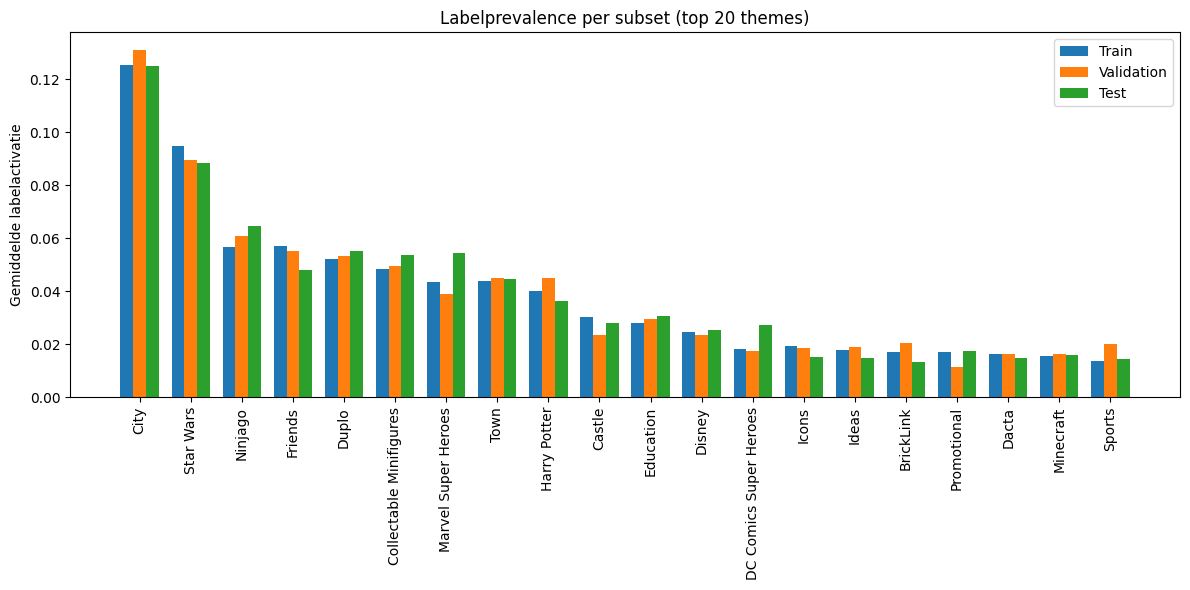


Splits opgeslagen in outputs_multilabel/


In [ ]:
# Eerst train+val en test splitsen
train_val_df, test_df = train_test_split(
    multi_model_df,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

# Daarna train en validation splitsen
val_relative_size = 0.15 / 0.85

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_relative_size,
    random_state=42,
    shuffle=True
)

# Basiscontrole
total = len(multi_model_df)

print("Split sizes:")
print(f"Train: {len(train_df)} ({len(train_df)/total:.4f})")
print(f"Val:   {len(val_df)} ({len(val_df)/total:.4f})")
print(f"Test:  {len(test_df)} ({len(test_df)/total:.4f})")

# Helper om gemiddelde labelactivatie per theme te berekenen
def label_prevalence(df_part):
    matrix = np.stack(df_part["target_vector"].values)
    return matrix.mean(axis=0)

train_prev = label_prevalence(train_df)
val_prev = label_prevalence(val_df)
test_prev = label_prevalence(test_df)

prevalence_df = pd.DataFrame({
    "theme": selected_themes,
    "train_prev": train_prev,
    "val_prev": val_prev,
    "test_prev": test_prev
})

print("\nExample of labelprevalence per theme:")
print(prevalence_df.head(15))

# Gemiddelde absolute verschillen tussen subsets
train_val_diff = np.mean(np.abs(prevalence_df["train_prev"] - prevalence_df["val_prev"]))
train_test_diff = np.mean(np.abs(prevalence_df["train_prev"] - prevalence_df["test_prev"]))

print("\nAverage absolute difference in labelprevalence:")
print(f"Train vs Val:  {train_val_diff:.6f}")
print(f"Train vs Test: {train_test_diff:.6f}")

# Aantal labels per minifig per subset
print("\nAverage number of labels per minifig:")
print(f"Train: {train_df['num_labels'].mean():.4f}")
print(f"Val:   {val_df['num_labels'].mean():.4f}")
print(f"Test:  {test_df['num_labels'].mean():.4f}")

# Visualisatie van prevalence voor top 20 meest voorkomende geselecteerde themes
top_themes = theme_counts.loc[selected_themes].sort_values(ascending=False).head(20).index.tolist()
plot_df = prevalence_df.set_index("theme").loc[top_themes]

plt.figure(figsize=(12, 6))
x = np.arange(len(plot_df))
width = 0.25

plt.bar(x - width, plot_df["train_prev"], width=width, label="Train")
plt.bar(x,         plot_df["val_prev"],   width=width, label="Validation")
plt.bar(x + width, plot_df["test_prev"],  width=width, label="Test")

plt.xticks(x, plot_df.index, rotation=90)
plt.ylabel("Average label activation")
plt.title("Labelprevalence per subset (top 20 themes)")
plt.legend()
plt.tight_layout()
plt.show()

# Splits opslaan
os.makedirs("outputs_multilabel", exist_ok=True)

train_df.to_pickle("outputs_multilabel/train_split_multilabel.pkl")
val_df.to_pickle("outputs_multilabel/val_split_multilabel.pkl")
test_df.to_pickle("outputs_multilabel/test_split_multilabel.pkl")

print("\nSplits saved in outputs_multilabel/")

## Deel 4: PyTorch `Dataset` en `DataLoader`s voor multilabel

In dit deel bouwen we de image pipeline voor het multilabel-probleem.

We passen de `Dataset`-klasse aan zodat elke observatie nu teruggeeft:
- een afbeeldingstensor
- een multi-hot targetvector van lengte 55

Daarna maken we `DataLoader`s voor train, validation en test, en doen we een sanity check op:
- de batchvorm van de afbeeldingen
- de batchvorm van de targets
- het datatype van de multilabel-targets

Voor multilabel-classification is het belangrijk dat de targets als numerieke vectors beschikbaar zijn, zodat we later een geschikte multilabel loss kunnen gebruiken.

In [ ]:
# Aangepaste Dataset voor multilabel targets
class MinifigMultilabelDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["full_path"]).convert("RGB")
        target = torch.tensor(row["target_vector"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, target

# Datasets maken
train_dataset = MinifigMultilabelDataset(train_df, transform=train_transforms)
val_dataset = MinifigMultilabelDataset(val_df, transform=eval_transforms)
test_dataset = MinifigMultilabelDataset(test_df, transform=eval_transforms)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

# DataLoaders maken
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Sanity check op één batch
images, targets = next(iter(train_loader))

print("\nImage batch shape:", images.shape)
print("Target batch shape:", targets.shape)
print("Target dtype:", targets.dtype)

# Controle van targetinhoud
print("\nNumber of active labels in first 10 examples of the batch:")
print(targets[:10].sum(dim=1))

# Controle van één sample
sample_image, sample_target = train_dataset[0]
print("\nSingle image tensor shape:", sample_image.shape)
print("Single target shape:", sample_target.shape)
print("Number of active labels in sample:", int(sample_target.sum().item()))

# Aantal outputlabels vastleggen
num_labels = len(selected_themes)
print("\nNumber of multilabel outputs:", num_labels)

Train dataset size: 11102
Val dataset size: 2379
Test dataset size: 2379

Image batch shape: torch.Size([64, 3, 224, 224])
Target batch shape: torch.Size([64, 55])
Target dtype: torch.float32

Aantal actieve labels in eerste 10 voorbeelden van de batch:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Single image tensor shape: torch.Size([3, 224, 224])
Single target shape: torch.Size([55])
Aantal actieve labels in sample: 1

Aantal multilabel outputs: 55


## Deel 5: baseline multilabel-model, loss en evaluatiefuncties

In dit deel bouwen we een eerste baseline-model voor het multilabel-probleem.

Omdat één afbeelding meerdere themes tegelijk kan hebben, verschilt deze setup van multiclass-classification op drie belangrijke punten:
1. de outputlaag heeft één neuron per theme
2. we gebruiken `BCEWithLogitsLoss` in plaats van `CrossEntropyLoss`
3. voorspellingen worden per label apart omgezet naar 0/1 via een sigmoid + threshold

Voor de evaluatie rapporteren we multilabel metrics:
- micro-F1
- macro-F1

Dit is inhoudelijk correct voor multilabel classification, waar meerdere uitkomsten tegelijk aanwezig kunnen zijn. De cursus maakt expliciet onderscheid tussen multiclass en multilabel classificatie. :contentReference[oaicite:0]{index=0}

In [ ]:
from sklearn.metrics import f1_score

# Baseline CNN voor multilabel
class SimpleMultilabelCNN(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 28 -> 14
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_labels)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# Model, loss en optimizer
multilabel_model = SimpleMultilabelCNN(num_labels=num_labels).to(device)
multilabel_criterion = nn.BCEWithLogitsLoss()
multilabel_optimizer = torch.optim.Adam(
    multilabel_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(multilabel_model)

# Helper: logits -> binaire voorspellingen
def logits_to_predictions(logits, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    return preds

# Eén epoch trainen
def train_one_epoch_multilabel(model, loader, criterion, optimizer, device, threshold=0.5):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = logits_to_predictions(logits, threshold=threshold)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    epoch_loss = running_loss / len(loader.dataset)
    micro_f1 = f1_score(all_targets, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, micro_f1, macro_f1

# Evaluatie
@torch.no_grad()
def evaluate_multilabel(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    all_probs = np.vstack(all_probs)

    epoch_loss = running_loss / len(loader.dataset)
    micro_f1 = f1_score(all_targets, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return epoch_loss, micro_f1, macro_f1, all_targets, all_preds, all_probs

# Training loop met early stopping op validation macro-F1
def train_model_multilabel(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=5,
    threshold=0.5,
    model_path="outputs_multilabel/best_multilabel_model.pt"
):
    best_macro_f1 = -1.0
    patience_counter = 0
    history = []

    for epoch in range(epochs):
        train_loss, train_micro_f1, train_macro_f1 = train_one_epoch_multilabel(
            model, train_loader, criterion, optimizer, device, threshold=threshold
        )

        val_loss, val_micro_f1, val_macro_f1, _, _, _ = evaluate_multilabel(
            model, val_loader, criterion, device, threshold=threshold
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_micro_f1": train_micro_f1,
            "train_macro_f1": train_macro_f1,
            "val_loss": val_loss,
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1
        }
        history.append(row)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f} | train_micro_f1={train_micro_f1:.4f} | train_macro_f1={train_macro_f1:.4f} | "
            f"val_loss={val_loss:.4f} | val_micro_f1={val_micro_f1:.4f} | val_macro_f1={val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    return history_df

# Sanity check: forward pass
multilabel_model.eval()
with torch.no_grad():
    sample_logits = multilabel_model(images.to(device))

print("\nOutput shape:", sample_logits.shape)
print("Expected shape:", (images.shape[0], num_labels))

sample_probs = torch.sigmoid(sample_logits[:2]).cpu()
print("\nExample of sigmoid probabilities for the first 2 examples:")
print(sample_probs[:, :10])

SimpleMultilabelCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): L

## Deel 6: baseline multilabel-model trainen

In dit deel trainen we het baseline CNN voor het multilabel-probleem.

We volgen tijdens training:
- training loss
- validation loss
- training micro-F1 en macro-F1
- validation micro-F1 en macro-F1

Voor modelselectie gebruiken we validation macro-F1, omdat die beter zichtbaar maakt of het model ook op minder dominante labels leert presteren.
Dat is belangrijk in deze multilabel-setting, waar de meeste minifigs maar één actief label hebben maar er toch duidelijke label-imbalance aanwezig is.

In [ ]:
import os
import matplotlib.pyplot as plt
##model met GPU getrained in Colab, gaf slechte resultaten!
os.makedirs("outputs_multilabel", exist_ok=True)

# Train het baseline multilabel-model
multilabel_history = train_model_multilabel(
    model=multilabel_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=multilabel_criterion,
    optimizer=multilabel_optimizer,
    device=device,
    epochs=20,
    patience=5,
    threshold=0.5,
    model_path="outputs_multilabel/baseline_multilabel_best.pt"
)

print("\nTraining history multilabel baseline:")
print(multilabel_history)

# Opslaan
multilabel_history.to_csv("outputs_multilabel/baseline_multilabel_history.csv", index=False)
print("\nHistory saved as outputs_multilabel/baseline_multilabel_history.csv")

# Beste epoch bepalen
best_idx = multilabel_history["val_macro_f1"].idxmax()
best_row = multilabel_history.loc[best_idx]

print("\nBest epoch on validation macro-F1:")
print(best_row)

# Plot 1: loss
plt.figure(figsize=(8, 5))
plt.plot(multilabel_history["epoch"], multilabel_history["train_loss"], label="Train loss")
plt.plot(multilabel_history["epoch"], multilabel_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Multilabel CNN - Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: micro-F1
plt.figure(figsize=(8, 5))
plt.plot(multilabel_history["epoch"], multilabel_history["train_micro_f1"], label="Train micro-F1")
plt.plot(multilabel_history["epoch"], multilabel_history["val_micro_f1"], label="Validation micro-F1")
plt.xlabel("Epoch")
plt.ylabel("Micro-F1")
plt.title("Baseline Multilabel CNN - Micro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: macro-F1
plt.figure(figsize=(8, 5))
plt.plot(multilabel_history["epoch"], multilabel_history["train_macro_f1"], label="Train macro-F1")
plt.plot(multilabel_history["epoch"], multilabel_history["val_macro_f1"], label="Validation macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Baseline Multilabel CNN - Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## Deel 6.5: beste multilabel-threshold zoeken op de validationset

De eerste trainingsresultaten tonen dat een standaard threshold van 0.5 hier waarschijnlijk te streng is.
Daarom zoeken we nu op de validationset welke globale threshold de beste multilabel-prestaties geeft.

We evalueren meerdere thresholds en vergelijken:
- micro-F1
- macro-F1
- gemiddeld aantal voorspelde labels per voorbeeld

Daarna kiezen we de threshold met de hoogste validation macro-F1.
Die threshold gebruiken we vervolgens voor de finale testevaluatie.

Threshold tuning results:
    threshold  val_micro_f1  val_macro_f1  avg_predicted_labels_per_example
0        0.01      0.081106      0.034414                         16.531315
1        0.02      0.102704      0.028906                         10.839428
2        0.05      0.134185      0.016499                          2.646070
3        0.08      0.148332      0.010958                          1.671291
4        0.10      0.082846      0.006633                          0.687264
5        0.12      0.019739      0.002175                          0.154687
6        0.15      0.006255      0.000835                          0.037411
7        0.20      0.000000      0.000000                          0.002102
8        0.25      0.000000      0.000000                          0.000841
9        0.30      0.000000      0.000000                          0.000000
10       0.40      0.000000      0.000000                          0.000000
11       0.50      0.000000      0.000000                     

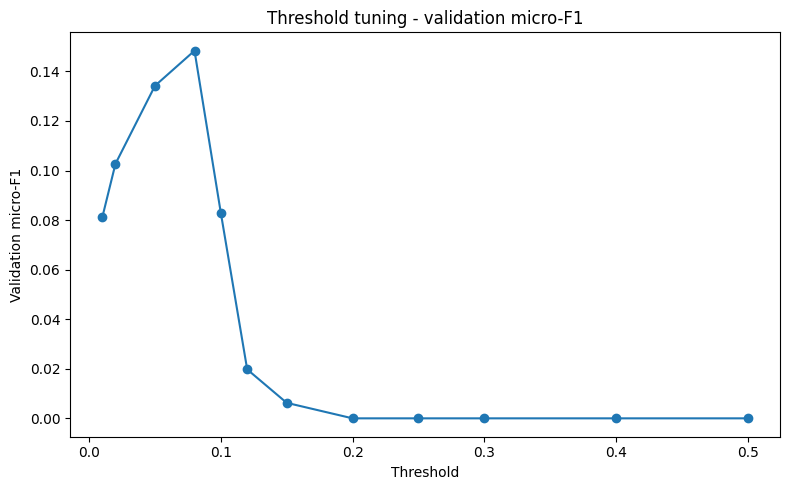

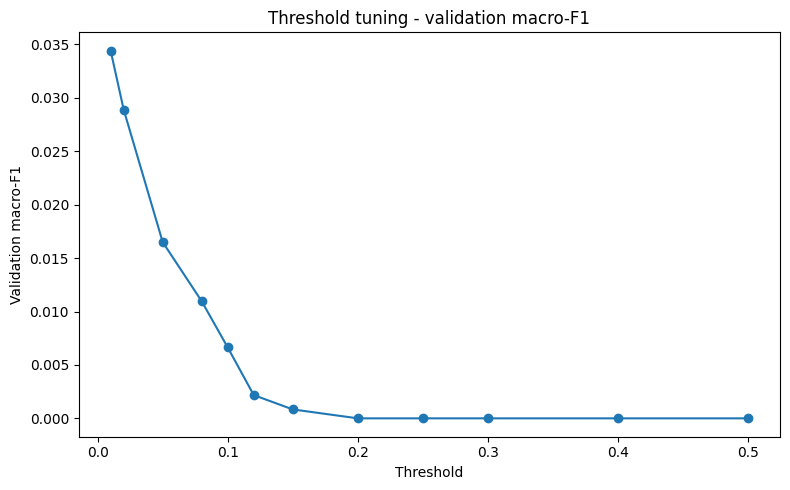

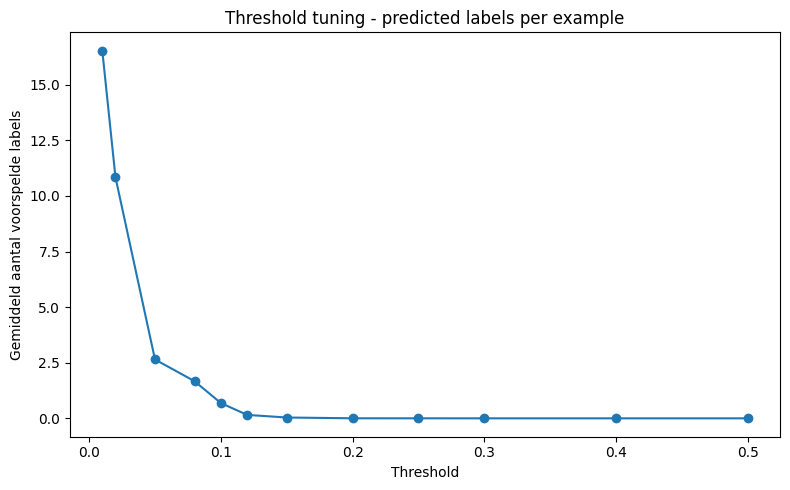


Bestand opgeslagen:
- outputs_multilabel/threshold_tuning_results.csv

Gekozen threshold: 0.0100


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Beste model opnieuw laden
best_multilabel_model = SimpleMultilabelCNN(num_labels=num_labels).to(device)
best_multilabel_model.load_state_dict(
    torch.load("outputs_multilabel/baseline_multilabel_best.pt", map_location=device)
)

# Eerst probabilities ophalen op validation set, zonder thresholding vooraf
@torch.no_grad()
def collect_probs_and_targets(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(targets.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    return all_probs, all_targets

val_probs, val_targets = collect_probs_and_targets(best_multilabel_model, val_loader, device)

# Threshold grid
thresholds = [0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

rows = []
for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(np.float32)

    micro_f1 = f1_score(val_targets, val_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
    avg_predicted_labels = val_preds.sum(axis=1).mean()

    rows.append({
        "threshold": threshold,
        "val_micro_f1": micro_f1,
        "val_macro_f1": macro_f1,
        "avg_predicted_labels_per_example": avg_predicted_labels
    })

threshold_results = pd.DataFrame(rows)

print("Threshold tuning results:")
print(threshold_results)

# Beste threshold kiezen op basis van validation macro-F1
best_idx = threshold_results["val_macro_f1"].idxmax()
best_threshold_row = threshold_results.loc[best_idx]
best_threshold = float(best_threshold_row["threshold"])

print("\nBest threshold on validation macro-F1:")
print(best_threshold_row)

threshold_results.to_csv("outputs_multilabel/threshold_tuning_results.csv", index=False)

# Plot micro-F1
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["val_micro_f1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation micro-F1")
plt.title("Threshold tuning - validation micro-F1")
plt.tight_layout()
plt.show()

# Plot macro-F1
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["val_macro_f1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation macro-F1")
plt.title("Threshold tuning - validation macro-F1")
plt.tight_layout()
plt.show()

# Plot aantal voorspelde labels
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["avg_predicted_labels_per_example"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Gemiddeld aantal voorspelde labels")
plt.title("Threshold tuning - predicted labels per example")
plt.tight_layout()
plt.show()

print("\nFile saved:")
print("- outputs_multilabel/threshold_tuning_results.csv")
print(f"\nChosen threshold: {best_threshold:.4f}")

## Deel 7: multilabel baseline evalueren op de testset

In dit deel evalueren we het beste multilabel baseline-model op de testset.

Omdat de standaard threshold van 0.5 in deze setting niet bruikbaar bleek, gebruiken we hier een lager gekozen threshold op basis van de validationset.
We kiezen een threshold die een beter compromis geeft tussen:
- F1-prestatie
- en een realistisch aantal voorspelde labels per voorbeeld

We rapporteren:
- test loss
- test micro-F1
- test macro-F1
- gemiddeld aantal voorspelde labels per voorbeeld
- prestaties per individueel theme

In [ ]:
from sklearn.metrics import f1_score
import json
import os

# Gekozen threshold op basis van validation-analyse
best_threshold = 0.08

# Beste model opnieuw laden
best_multilabel_model = SimpleMultilabelCNN(num_labels=num_labels).to(device)
best_multilabel_model.load_state_dict(
    torch.load("outputs_multilabel/baseline_multilabel_best.pt", map_location=device)
)

# Testevaluatie
test_loss, test_micro_f1, test_macro_f1, test_targets, test_preds, test_probs = evaluate_multilabel(
    best_multilabel_model,
    test_loader,
    multilabel_criterion,
    device,
    threshold=best_threshold
)

print("Multilabel baseline - Test results:")
print(f"Threshold: {best_threshold:.2f}")
print(f"loss={test_loss:.4f}")
print(f"micro_f1={test_micro_f1:.4f}")
print(f"macro_f1={test_macro_f1:.4f}")

avg_predicted_labels = test_preds.sum(axis=1).mean()
avg_true_labels = test_targets.sum(axis=1).mean()

print(f"\nAverage number of true labels per example: {avg_true_labels:.4f}")
print(f"Average number of predicted labels per example: {avg_predicted_labels:.4f}")

# Per theme F1 berekenen
per_theme_rows = []
for idx, theme in enumerate(selected_themes):
    y_true = test_targets[:, idx]
    y_pred = test_preds[:, idx]

    theme_f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    per_theme_rows.append({
        "theme": theme,
        "support": support,
        "f1": theme_f1
    })

per_theme_df = pd.DataFrame(per_theme_rows).sort_values("f1", ascending=False)

print("\nTop 15 best scoring themes:")
print(per_theme_df.head(15))

print("\nTop 15 worst scoring themes:")
print(per_theme_df.tail(15))

# Opslaan
os.makedirs("outputs_multilabel", exist_ok=True)
per_theme_df.to_csv("outputs_multilabel/test_per_theme_metrics_baseline.csv", index=False)

summary = {
    "threshold": float(best_threshold),
    "test_loss": float(test_loss),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_f1": float(test_macro_f1),
    "avg_true_labels_per_example": float(avg_true_labels),
    "avg_predicted_labels_per_example": float(avg_predicted_labels)
}

with open("outputs_multilabel/baseline_multilabel_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nFiles saved:")
print("- outputs_multilabel/test_per_theme_metrics_baseline.csv")
print("- outputs_multilabel/baseline_multilabel_summary.json")

Multilabel baseline - Test results:
Threshold: 0.08
loss=0.0867
micro_f1=0.1496
macro_f1=0.0109

Gemiddeld aantal echte labels per voorbeeld: 1.0412
Gemiddeld aantal voorspelde labels per voorbeeld: 1.6398

Top 15 best scorende themes:
                     theme  support        f1
0                     City      297  0.228023
1                Star Wars      210  0.209869
3                  Friends      114  0.111111
4                    Duplo      131  0.028986
8             Harry Potter       86  0.020000
42        The LEGO Movie 2       15  0.000000
32           Miscellaneous       18  0.000000
33          Jurassic World       15  0.000000
34                  Trains       24  0.000000
35                   Games       20  0.000000
36                Belville       15  0.000000
37                Dreamzzz       13  0.000000
38         Advanced models       19  0.000000
39   The LEGO Batman Movie       14  0.000000
40  The LEGO Ninjago Movie       12  0.000000

Top 15 slechtst scorende th

## Deel 8: EfficientNet-B0 met gewogen multilabel loss opzetten

De baseline multilabel-CNN presteert zwak, vooral op de minder frequente themes.
Daarom stappen we nu over naar een sterker model: een pretrained EfficientNet-B0.

Daarnaast passen we ook de loss function aan.
Omdat sommige themes veel zeldzamer zijn dan andere, gebruiken we een gewogen versie van `BCEWithLogitsLoss` via `pos_weight`.
Daardoor wordt het model sterker gestimuleerd om ook zeldzamere positieve labels te leren.

In deze stap doen we alleen de setup:
- de multilabel class imbalance berekenen op de trainingsset
- `pos_weight` opbouwen
- EfficientNet-B0 initialiseren
- backbone freezen
- classifier vervangen
- weighted loss en optimizer instellen
- een sanity check doen op de outputdimensie

In [ ]:
from torchvision import models

# -----------------------------
# 1. pos_weight berekenen op basis van de trainingsset
# -----------------------------
train_target_matrix = np.stack(train_df["target_vector"].values)  # shape: [n_samples, num_labels]

positive_counts = train_target_matrix.sum(axis=0)
negative_counts = len(train_target_matrix) - positive_counts

# Vermijd delen door nul
positive_counts = np.clip(positive_counts, a_min=1.0, a_max=None)

pos_weight = negative_counts / positive_counts
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

pos_weight_df = pd.DataFrame({
    "theme": selected_themes,
    "positive_count": positive_counts.astype(int),
    "negative_count": negative_counts.astype(int),
    "pos_weight": pos_weight
}).sort_values("pos_weight", ascending=False)

print("Top 15 highest pos_weight themes:")
print(pos_weight_df.head(15))

print("\nTop 15 lowest pos_weight themes:")
print(pos_weight_df.tail(15))

# -----------------------------
# 2. EfficientNet-B0 opbouwen
# -----------------------------
effnet_multilabel_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Backbone freezen
for param in effnet_multilabel_model.features.parameters():
    param.requires_grad = False

# Classifier vervangen voor multilabel output
in_features = effnet_multilabel_model.classifier[1].in_features
effnet_multilabel_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, num_labels)
)

effnet_multilabel_model = effnet_multilabel_model.to(device)

# -----------------------------
# 3. Weighted multilabel loss + optimizer
# -----------------------------
effnet_multilabel_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

effnet_multilabel_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, effnet_multilabel_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

print("\nEfficientNet multilabel model:")
print(effnet_multilabel_model)

# -----------------------------
# 4. Parametercontrole
# -----------------------------
total_params = sum(p.numel() for p in effnet_multilabel_model.parameters())
trainable_params = sum(p.numel() for p in effnet_multilabel_model.parameters() if p.requires_grad)

print(f"\nTotal number of parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# -----------------------------
# 5. Sanity check op één batch
# -----------------------------
effnet_multilabel_model.eval()
with torch.no_grad():
    sample_logits = effnet_multilabel_model(images.to(device))

print("\nOutput shape:", sample_logits.shape)
print("Expected shape:", (images.shape[0], num_labels))

sample_probs = torch.sigmoid(sample_logits[:2]).cpu()
print("\nExample of sigmoid probabilities for first 2 examples:")
print(sample_probs[:, :10])

# -----------------------------
# 6. pos_weight opslaan
# -----------------------------
os.makedirs("outputs_multilabel", exist_ok=True)
pos_weight_df.to_csv("outputs_multilabel/pos_weight_table.csv", index=False)

print("\nFile saved:")
print("- outputs_multilabel/pos_weight_table.csv")

Top 15 hoogste pos_weight themes:
                           theme  positive_count  negative_count  pos_weight
54                   Adventurers              34           11068  325.529419
52                          Cars              36           11066  307.388885
50                         Basic              36           11066  307.388885
53  Teenage Mutant Ninja Turtles              40           11062  276.549988
51                 Indiana Jones              40           11062  276.549988
49                         Elves              45           11057  245.711105
48                    The Hobbit              45           11057  245.711105
46                   Hidden Side              46           11056  240.347824
45                The LEGO Movie              52           11050  212.500000
47                    Dimensions              54           11048  204.592590
42              The LEGO Movie 2              55           11047  200.854538
44                        Racers          

## Deel 9: EfficientNet-B0 multilabel trainen met weighted loss

In dit deel trainen we het pretrained EfficientNet-B0 model voor het multilabel-probleem.

We gebruiken:
- een gefreezede backbone
- een nieuwe multilabel-classifier head
- een gewogen `BCEWithLogitsLoss` via `pos_weight`
- early stopping op validation macro-F1

Omdat een threshold van 0.5 in deze setting te streng bleek, gebruiken we tijdens de monitoring tijdelijk een lagere threshold van 0.08.
Na de training zullen we de threshold opnieuw afzonderlijk tunen op de validation set.

Dit experiment moet uitwijzen of een sterker pretrained beeldmodel, gecombineerd met cost-sensitive training, de multilabel-prestaties duidelijk kan verbeteren.

Epoch 01 | train_loss=1.1438 | train_micro_f1=0.0380 | train_macro_f1=0.0372 | val_loss=0.9267 | val_micro_f1=0.0394 | val_macro_f1=0.0401
Epoch 02 | train_loss=0.8430 | train_micro_f1=0.0415 | train_macro_f1=0.0428 | val_loss=0.8142 | val_micro_f1=0.0438 | val_macro_f1=0.0472
Epoch 03 | train_loss=0.7515 | train_micro_f1=0.0456 | train_macro_f1=0.0479 | val_loss=0.7612 | val_micro_f1=0.0473 | val_macro_f1=0.0526
Epoch 04 | train_loss=0.7052 | train_micro_f1=0.0491 | train_macro_f1=0.0521 | val_loss=0.7316 | val_micro_f1=0.0500 | val_macro_f1=0.0564
Epoch 05 | train_loss=0.6694 | train_micro_f1=0.0519 | train_macro_f1=0.0550 | val_loss=0.7153 | val_micro_f1=0.0527 | val_macro_f1=0.0590
Epoch 06 | train_loss=0.6434 | train_micro_f1=0.0543 | train_macro_f1=0.0576 | val_loss=0.6979 | val_micro_f1=0.0558 | val_macro_f1=0.0641
Epoch 07 | train_loss=0.6196 | train_micro_f1=0.0565 | train_macro_f1=0.0599 | val_loss=0.6904 | val_micro_f1=0.0561 | val_macro_f1=0.0638
Epoch 08 | train_loss=0.601

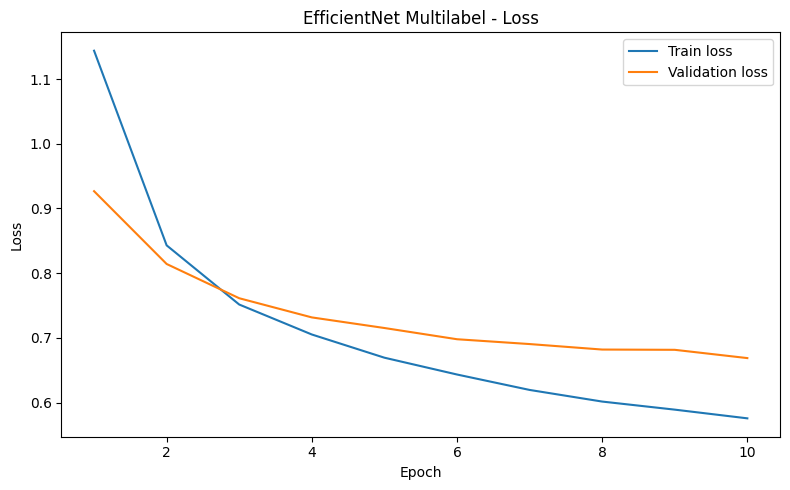

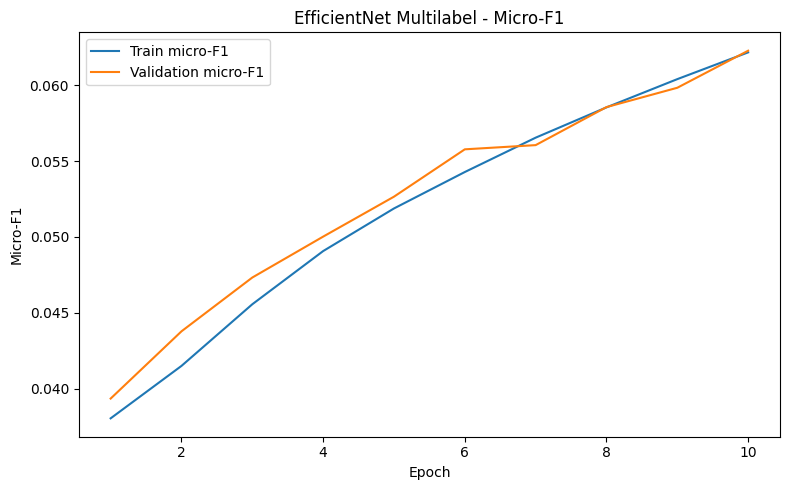

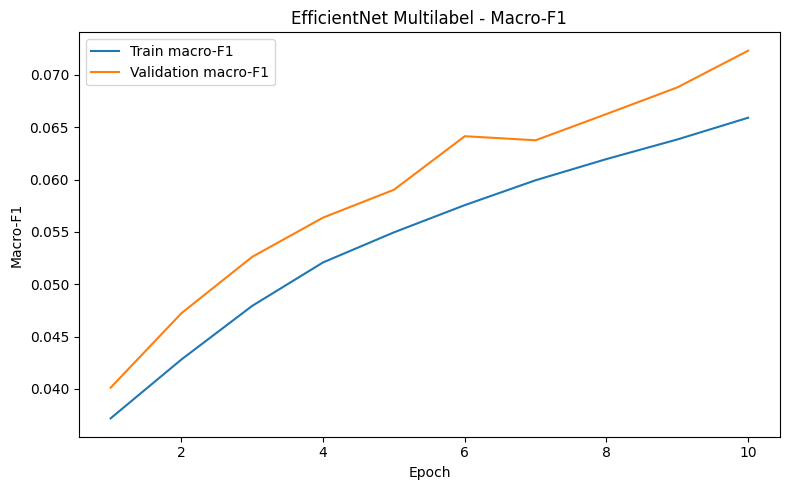

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs_multilabel", exist_ok=True)

MONITOR_THRESHOLD = 0.08

# EfficientNet multilabel trainen
effnet_multilabel_history = train_model_multilabel(
    model=effnet_multilabel_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=effnet_multilabel_criterion,
    optimizer=effnet_multilabel_optimizer,
    device=device,
    epochs=10,
    patience=3,
    threshold=MONITOR_THRESHOLD,
    model_path="outputs_multilabel/effnet_multilabel_best.pt"
)

print("\nTraining history EfficientNet multilabel:")
print(effnet_multilabel_history)

# Historiek opslaan
effnet_multilabel_history.to_csv(
    "outputs_multilabel/effnet_multilabel_history.csv",
    index=False
)
print("\nTraining history saved as outputs_multilabel/effnet_multilabel_history.csv")

# Beste epoch bepalen
best_idx = effnet_multilabel_history["val_macro_f1"].idxmax()
best_row = effnet_multilabel_history.loc[best_idx]

print("\nBest epoch on validation macro-F1:")
print(best_row)

# Plot 1: loss
plt.figure(figsize=(8, 5))
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["train_loss"], label="Train loss")
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet Multilabel - Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: micro-F1
plt.figure(figsize=(8, 5))
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["train_micro_f1"], label="Train micro-F1")
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["val_micro_f1"], label="Validation micro-F1")
plt.xlabel("Epoch")
plt.ylabel("Micro-F1")
plt.title("EfficientNet Multilabel - Micro-F1")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: macro-F1
plt.figure(figsize=(8, 5))
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["train_macro_f1"], label="Train macro-F1")
plt.plot(effnet_multilabel_history["epoch"], effnet_multilabel_history["val_macro_f1"], label="Validation macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("EfficientNet Multilabel - Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

## Deel 10: threshold tuning voor EfficientNet multilabel op de validationset

In dit deel zoeken we de beste globale threshold voor het EfficientNet-multilabelmodel.

Tijdens training gebruikten we tijdelijk een threshold van 0.08 om de leerhistoriek te monitoren, maar dat hoeft niet de optimale eindthreshold te zijn.
Daarom evalueren we nu meerdere thresholds op de validationset en vergelijken we:
- micro-F1
- macro-F1
- gemiddeld aantal voorspelde labels per voorbeeld

Daarna kiezen we een threshold die zowel goede F1-prestaties geeft als een realistisch aantal voorspelde labels oplevert.

Threshold tuning results for EfficientNet multilabel:
    threshold  val_micro_f1  val_macro_f1  avg_predicted_labels_per_example
0        0.01      0.043875      0.044590                         46.194199
1        0.02      0.047295      0.049805                         42.761246
2        0.05      0.055221      0.061817                         36.367802
3        0.08      0.062272      0.072309                         32.051281
4        0.10      0.066755      0.078488                         29.715847
5        0.12      0.071162      0.084313                         27.693148
6        0.15      0.078015      0.092919                         25.050861
7        0.20      0.089520      0.106678                         21.416142
8        0.25      0.102739      0.121013                         18.347204
9        0.30      0.115923      0.134050                         15.888609
10       0.40      0.147265      0.164454                         11.823875
11       0.50      0.185409      0

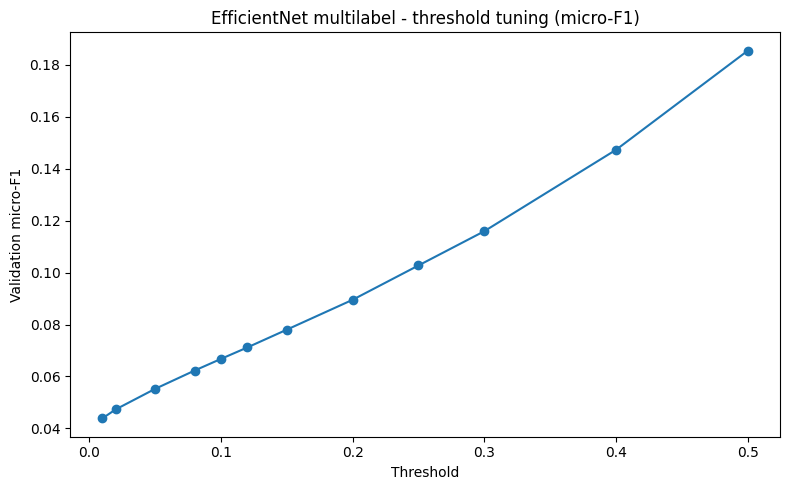

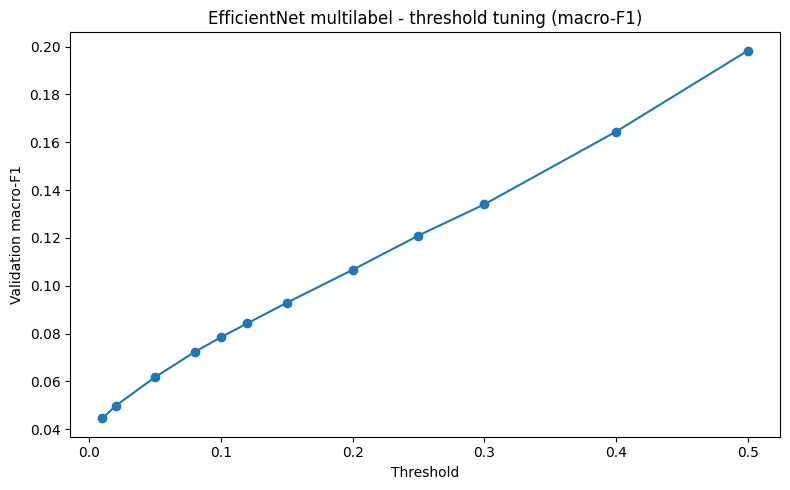

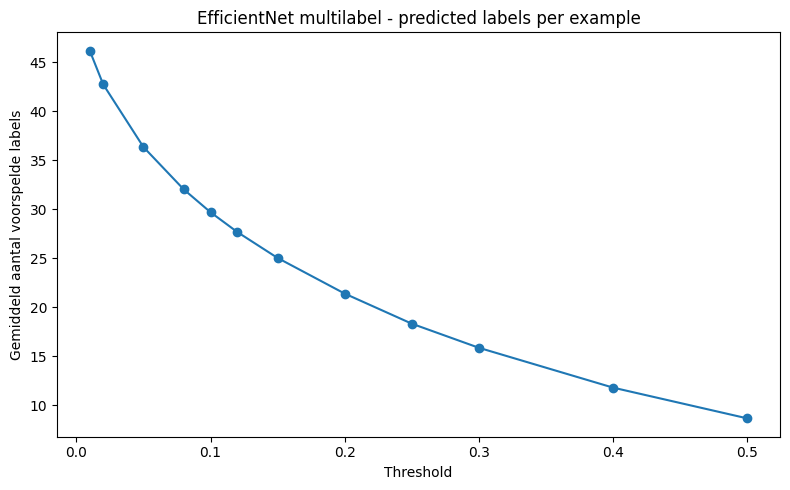


Bestand opgeslagen:
- outputs_multilabel/effnet_threshold_tuning_results.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Beste EfficientNet-model opnieuw laden
best_effnet_multilabel_model = models.efficientnet_b0(
    weights=None
)

in_features = best_effnet_multilabel_model.classifier[1].in_features
best_effnet_multilabel_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, num_labels)
)

best_effnet_multilabel_model = best_effnet_multilabel_model.to(device)
best_effnet_multilabel_model.load_state_dict(
    torch.load("outputs_multilabel/effnet_multilabel_best.pt", map_location=device)
)

# Helper: probabilities en targets verzamelen
@torch.no_grad()
def collect_probs_and_targets(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(targets.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)
    return all_probs, all_targets

val_probs, val_targets = collect_probs_and_targets(
    best_effnet_multilabel_model,
    val_loader,
    device
)

# Threshold grid
thresholds = [0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

rows = []
for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(np.float32)

    micro_f1 = f1_score(val_targets, val_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
    avg_predicted_labels = val_preds.sum(axis=1).mean()

    rows.append({
        "threshold": threshold,
        "val_micro_f1": micro_f1,
        "val_macro_f1": macro_f1,
        "avg_predicted_labels_per_example": avg_predicted_labels
    })

effnet_threshold_results = pd.DataFrame(rows)

print("Threshold tuning results for EfficientNet multilabel:")
print(effnet_threshold_results)

# Beste threshold volgens macro-F1
best_idx_macro = effnet_threshold_results["val_macro_f1"].idxmax()
best_macro_row = effnet_threshold_results.loc[best_idx_macro]

# Beste threshold volgens micro-F1
best_idx_micro = effnet_threshold_results["val_micro_f1"].idxmax()
best_micro_row = effnet_threshold_results.loc[best_idx_micro]

print("\nBest threshold on validation macro-F1:")
print(best_macro_row)

print("\nBest threshold on validation micro-F1:")
print(best_micro_row)

# Opslaan
effnet_threshold_results.to_csv(
    "outputs_multilabel/effnet_threshold_tuning_results.csv",
    index=False
)

# Plot micro-F1
plt.figure(figsize=(8, 5))
plt.plot(effnet_threshold_results["threshold"], effnet_threshold_results["val_micro_f1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation micro-F1")
plt.title("EfficientNet multilabel - threshold tuning (micro-F1)")
plt.tight_layout()
plt.show()

# Plot macro-F1
plt.figure(figsize=(8, 5))
plt.plot(effnet_threshold_results["threshold"], effnet_threshold_results["val_macro_f1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation macro-F1")
plt.title("EfficientNet multilabel - threshold tuning (macro-F1)")
plt.tight_layout()
plt.show()

# Plot gemiddeld aantal voorspelde labels
plt.figure(figsize=(8, 5))
plt.plot(
    effnet_threshold_results["threshold"],
    effnet_threshold_results["avg_predicted_labels_per_example"],
    marker="o"
)
plt.xlabel("Threshold")
plt.ylabel("Average number of predicted labels")
plt.title("EfficientNet multilabel - predicted labels per example")
plt.tight_layout()
plt.show()

print("\nFile saved:")
print("- outputs_multilabel/effnet_threshold_tuning_results.csv")

## Deel 11: EfficientNet multilabel evalueren op de testset

In dit deel evalueren we het beste EfficientNet-multilabelmodel op de onafhankelijke testset.

Methodologisch volgt dit de logica uit de cursus:
- de testset wordt alleen gebruikt voor de finale evaluatie
- modelkeuzes gebeuren op de validationset
- de threshold wordt dus niet meer op de testset afgestemd

Omdat de threshold tuning op de validationset aantoonde dat `0.50` hier de beste micro-F1 en macro-F1 gaf, gebruiken we die threshold nu voor de eerste finale testevaluatie van het EfficientNet-model.

We rapporteren:
- test loss
- test micro-F1
- test macro-F1
- gemiddeld aantal echte labels per voorbeeld
- gemiddeld aantal voorspelde labels per voorbeeld
- per-theme F1 en support
- top 15 best scorende themes
- top 15 slechtst scorende themes

Daarnaast slaan we alle relevante resultaten op in `outputs_multilabel/`, zodat ze later rechtstreeks gebruikt kunnen worden in de vergelijking en bespreking.

In [ ]:
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import json
import os
from torchvision import models

os.makedirs("outputs_multilabel", exist_ok=True)

# --------------------------------------------------
# Gekozen threshold op basis van validation tuning
# --------------------------------------------------
efficientnet_test_threshold = 0.50

# --------------------------------------------------
# Beste EfficientNet-model opnieuw opbouwen en laden
# --------------------------------------------------
best_effnet_multilabel_model = models.efficientnet_b0(weights=None)

in_features = best_effnet_multilabel_model.classifier[1].in_features
best_effnet_multilabel_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, num_labels)
)

best_effnet_multilabel_model = best_effnet_multilabel_model.to(device)
best_effnet_multilabel_model.load_state_dict(
    torch.load("outputs_multilabel/effnet_multilabel_best.pt", map_location=device)
)

# --------------------------------------------------
# Testevaluatie uitvoeren
# --------------------------------------------------
test_loss, test_micro_f1, test_macro_f1, test_targets, test_preds, test_probs = evaluate_multilabel(
    best_effnet_multilabel_model,
    test_loader,
    effnet_multilabel_criterion,
    device,
    threshold=efficientnet_test_threshold
)

avg_true_labels = test_targets.sum(axis=1).mean()
avg_predicted_labels = test_preds.sum(axis=1).mean()

print("EfficientNet multilabel - Test results:")
print(f"Threshold: {efficientnet_test_threshold:.2f}")
print(f"loss={test_loss:.4f}")
print(f"micro_f1={test_micro_f1:.4f}")
print(f"macro_f1={test_macro_f1:.4f}")

print(f"\nAverage number of true labels per example: {avg_true_labels:.4f}")
print(f"Average number of predicted labels per example: {avg_predicted_labels:.4f}")

# --------------------------------------------------
# Per-theme metrics berekenen
# --------------------------------------------------
per_theme_rows = []

for idx, theme in enumerate(selected_themes):
    y_true = test_targets[:, idx]
    y_pred = test_preds[:, idx]

    theme_f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    per_theme_rows.append({
        "theme": theme,
        "support": support,
        "f1": theme_f1
    })

effnet_test_per_theme_df = pd.DataFrame(per_theme_rows)

# Voor overzicht:
# - best scorende themes: hoogste F1 eerst
# - slechtst scorende themes: laagste F1 eerst
# Bij gelijke F1 sorteren we op support
effnet_test_per_theme_sorted_desc = effnet_test_per_theme_df.sort_values(
    by=["f1", "support", "theme"],
    ascending=[False, False, True]
).reset_index(drop=True)

effnet_test_per_theme_sorted_asc = effnet_test_per_theme_df.sort_values(
    by=["f1", "support", "theme"],
    ascending=[True, True, True]
).reset_index(drop=True)

top_15_best_themes = effnet_test_per_theme_sorted_desc.head(15)
top_15_worst_themes = effnet_test_per_theme_sorted_asc.head(15)

print("\nTop 15 best scoring themes:")
print(top_15_best_themes.to_string(index=False))

print("\nTop 15 worst scoring themes:")
print(top_15_worst_themes.to_string(index=False))

print("\nFull per-theme table:")
print(
    effnet_test_per_theme_sorted_desc[["theme", "support", "f1"]]
    .to_string(index=False)
)

# --------------------------------------------------
# Resultaten opslaan
# --------------------------------------------------
effnet_test_per_theme_df.to_csv(
    "outputs_multilabel/effnet_test_per_theme_metrics.csv",
    index=False
)

top_15_best_themes.to_csv(
    "outputs_multilabel/effnet_test_top15_best_themes.csv",
    index=False
)

top_15_worst_themes.to_csv(
    "outputs_multilabel/effnet_test_top15_worst_themes.csv",
    index=False
)

effnet_test_summary = {
    "threshold": float(efficientnet_test_threshold),
    "test_loss": float(test_loss),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_f1": float(test_macro_f1),
    "avg_true_labels_per_example": float(avg_true_labels),
    "avg_predicted_labels_per_example": float(avg_predicted_labels)
}

with open("outputs_multilabel/effnet_multilabel_test_summary.json", "w", encoding="utf-8") as f:
    json.dump(effnet_test_summary, f, indent=2)

# Optioneel ook ruwe arrays bewaren voor latere analyse
np.save("outputs_multilabel/effnet_test_targets.npy", test_targets)
np.save("outputs_multilabel/effnet_test_predictions.npy", test_preds)
np.save("outputs_multilabel/effnet_test_probabilities.npy", test_probs)

print("\nFiles saved:")
print("- outputs_multilabel/effnet_test_per_theme_metrics.csv")
print("- outputs_multilabel/effnet_test_top15_best_themes.csv")
print("- outputs_multilabel/effnet_test_top15_worst_themes.csv")
print("- outputs_multilabel/effnet_multilabel_test_summary.json")
print("- outputs_multilabel/effnet_test_targets.npy")
print("- outputs_multilabel/effnet_test_predictions.npy")
print("- outputs_multilabel/effnet_test_probabilities.npy")

EfficientNet multilabel - Test results:
Threshold: 0.50
loss=0.6890
micro_f1=0.1883
macro_f1=0.2021

Gemiddeld aantal echte labels per voorbeeld: 1.0412
Gemiddeld aantal voorspelde labels per voorbeeld: 8.5725

Top 15 best scorende themes:
                  theme  support       f1
              Minecraft       38 0.686275
                Friends      114 0.658683
                  Duplo      131 0.587963
            Super Mario       40 0.541667
                   City      297 0.518000
               Belville       15 0.482759
              Star Wars      210 0.474534
                Ninjago      154 0.472414
                  Games       20 0.461538
                   Town      106 0.402464
               Fabuland       13 0.346667
                 Castle       67 0.329670
           Harry Potter       86 0.317881
                 Disney       60 0.280323
Collectable Minifigures      128 0.263819

Top 15 slechtst scorende themes:
                       theme  support       f1
Teenage

## Deel 12: baseline multilabel en EfficientNet multilabel rechtstreeks vergelijken

In dit deel vergelijken we de twee multilabelmodellen rechtstreeks op de testset:
- de baseline CNN
- het EfficientNet-B0 model met weighted loss

We doen die vergelijking op een methodologisch correcte manier:
- beide modellen worden geëvalueerd op dezelfde testset
- de gebruikte thresholds zijn telkens vooraf gekozen op basis van de validationset
- de testset wordt hier dus enkel gebruikt voor de finale vergelijking

We vergelijken zowel de globale prestaties als de prestaties per theme.

Globaal bekijken we:
- test loss
- test micro-F1
- test macro-F1
- gemiddeld aantal echte labels per voorbeeld
- gemiddeld aantal voorspelde labels per voorbeeld

Daarnaast bekijken we ook per theme:
- de F1 van de baseline
- de F1 van EfficientNet
- het verschil tussen beide modellen

Zo kunnen we niet alleen zien of EfficientNet gemiddeld beter scoort, maar ook op welke themes de winst het grootst is en waar beide modellen zwak blijven.

Globale vergelijking op de testset:
          model  threshold  test_loss  test_micro_f1  test_macro_f1  avg_true_labels_per_example  avg_predicted_labels_per_example
   Baseline CNN       0.08   0.086741       0.149577       0.010873                     1.041194                          1.639765
EfficientNet-B0       0.50   0.688998       0.188273       0.202090                     1.041194                          8.572510

Verschillen:
                             model  threshold  test_loss  test_micro_f1  test_macro_f1  avg_true_labels_per_example  avg_predicted_labels_per_example
Verschil (EfficientNet - Baseline)       0.42   0.602257       0.038697       0.191218                          0.0                          6.932745

Top 15 grootste verbeteringen per theme:
                  theme  support  baseline_f1  effnet_f1  f1_improvement
              Minecraft       38     0.000000   0.686275        0.686275
                  Duplo      131     0.028986   0.587963        0.558

<Figure size 800x500 with 0 Axes>

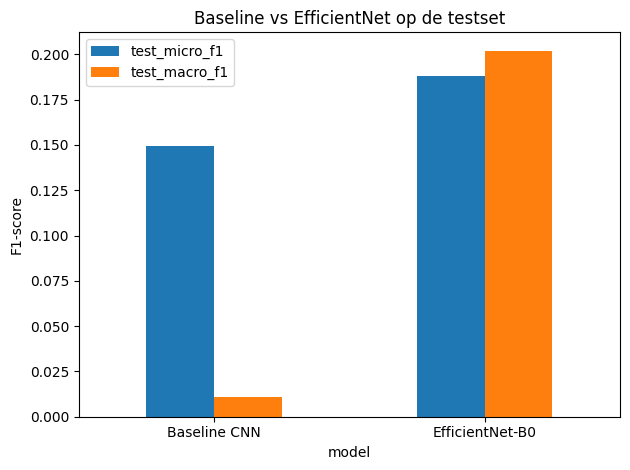

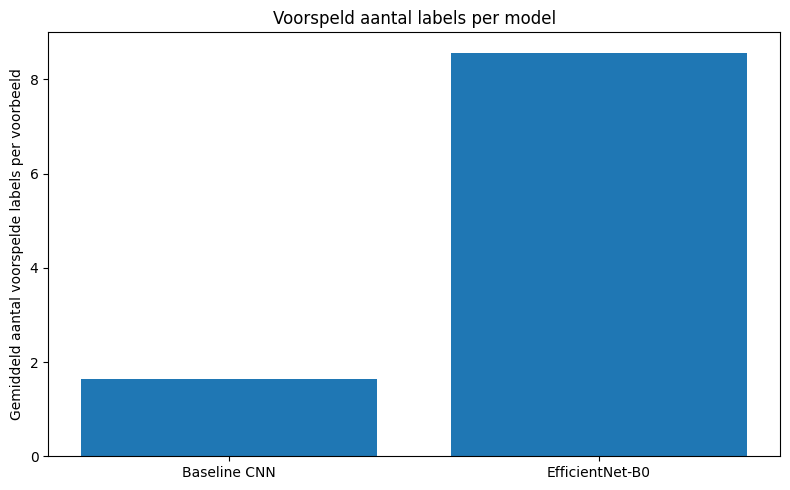

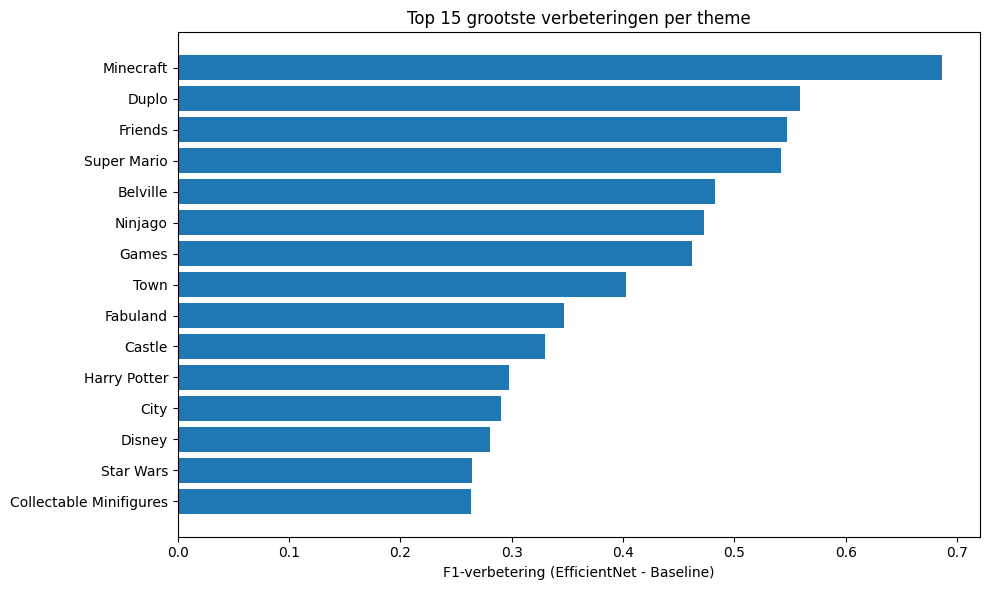


Bestanden opgeslagen:
- outputs_multilabel/model_comparison_baseline_vs_effnet.csv
- outputs_multilabel/model_comparison_deltas.csv
- outputs_multilabel/per_theme_comparison_baseline_vs_effnet.csv
- outputs_multilabel/best_effnet_themes_with_baseline_reference.csv
- outputs_multilabel/worst_effnet_themes_with_baseline_reference.csv
- outputs_multilabel/model_comparison_summary.json


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("outputs_multilabel", exist_ok=True)

# --------------------------------------------------
# 1. Samenvattingen van beide modellen inladen
# --------------------------------------------------
with open("outputs_multilabel/baseline_multilabel_summary.json", "r", encoding="utf-8") as f:
    baseline_summary = json.load(f)

with open("outputs_multilabel/effnet_multilabel_test_summary.json", "r", encoding="utf-8") as f:
    effnet_summary = json.load(f)

baseline_per_theme = pd.read_csv("outputs_multilabel/test_per_theme_metrics_baseline.csv")
effnet_per_theme = pd.read_csv("outputs_multilabel/effnet_test_per_theme_metrics.csv")

# --------------------------------------------------
# 2. Globale vergelijking op testset
# --------------------------------------------------
comparison_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "threshold": baseline_summary["threshold"],
        "test_loss": baseline_summary["test_loss"],
        "test_micro_f1": baseline_summary["test_micro_f1"],
        "test_macro_f1": baseline_summary["test_macro_f1"],
        "avg_true_labels_per_example": baseline_summary["avg_true_labels_per_example"],
        "avg_predicted_labels_per_example": baseline_summary["avg_predicted_labels_per_example"],
    },
    {
        "model": "EfficientNet-B0",
        "threshold": effnet_summary["threshold"],
        "test_loss": effnet_summary["test_loss"],
        "test_micro_f1": effnet_summary["test_micro_f1"],
        "test_macro_f1": effnet_summary["test_macro_f1"],
        "avg_true_labels_per_example": effnet_summary["avg_true_labels_per_example"],
        "avg_predicted_labels_per_example": effnet_summary["avg_predicted_labels_per_example"],
    }
])

print("Global comparison on the testset:")
print(comparison_df.to_string(index=False))

# Extra verschilrij
delta_row = pd.DataFrame([{
    "model": "Difference (EfficientNet - Baseline)",
    "threshold": effnet_summary["threshold"] - baseline_summary["threshold"],
    "test_loss": effnet_summary["test_loss"] - baseline_summary["test_loss"],
    "test_micro_f1": effnet_summary["test_micro_f1"] - baseline_summary["test_micro_f1"],
    "test_macro_f1": effnet_summary["test_macro_f1"] - baseline_summary["test_macro_f1"],
    "avg_true_labels_per_example": effnet_summary["avg_true_labels_per_example"] - baseline_summary["avg_true_labels_per_example"],
    "avg_predicted_labels_per_example": effnet_summary["avg_predicted_labels_per_example"] - baseline_summary["avg_predicted_labels_per_example"],
}])

print("\nDifferences:")
print(delta_row.to_string(index=False))

# --------------------------------------------------
# 3. Per-theme vergelijking maken
# --------------------------------------------------
baseline_per_theme = baseline_per_theme.rename(columns={
    "f1": "baseline_f1",
    "support": "support_baseline"
})

effnet_per_theme = effnet_per_theme.rename(columns={
    "f1": "effnet_f1",
    "support": "support_effnet"
})

per_theme_comparison = baseline_per_theme.merge(
    effnet_per_theme,
    on="theme",
    how="inner"
)

# Support hoort identiek te zijn; we houden één support-kolom over
per_theme_comparison["support"] = per_theme_comparison["support_effnet"]

per_theme_comparison = per_theme_comparison[[
    "theme",
    "support",
    "baseline_f1",
    "effnet_f1"
]].copy()

per_theme_comparison["f1_improvement"] = (
    per_theme_comparison["effnet_f1"] - per_theme_comparison["baseline_f1"]
)

per_theme_comparison = per_theme_comparison.sort_values(
    by="f1_improvement",
    ascending=False
).reset_index(drop=True)

print("\nTop 15 grootste verbeteringen per theme:")
print(per_theme_comparison.head(15).to_string(index=False))

print("\nTop 15 kleinste / negatiefste verbeteringen per theme:")
print(per_theme_comparison.tail(15).to_string(index=False))

# --------------------------------------------------
# 4. Enkele samenvattende tellingen
# --------------------------------------------------
n_better = (per_theme_comparison["f1_improvement"] > 0).sum()
n_equal = (per_theme_comparison["f1_improvement"] == 0).sum()
n_worse = (per_theme_comparison["f1_improvement"] < 0).sum()

print("\nNumber of themes where EfficientNet performs better / equally / worse:")
print(f"Better : {n_better}")
print(f"Equally: {n_equal}")
print(f"Worse  : {n_worse}")

# --------------------------------------------------
# 5. Sorteer ook op EfficientNet F1 voor overzicht
# --------------------------------------------------
best_effnet_themes = per_theme_comparison.sort_values(
    by=["effnet_f1", "support", "theme"],
    ascending=[False, False, True]
).head(15)

worst_effnet_themes = per_theme_comparison.sort_values(
    by=["effnet_f1", "support", "theme"],
    ascending=[True, True, True]
).head(15)

print("\nTop 15 themes according to EfficientNet F1 (with baseline as reference):")
print(best_effnet_themes.to_string(index=False))

print("\nWorst 15 themes according to EfficientNet F1 (with baseline as reference):")
print(worst_effnet_themes.to_string(index=False))

# --------------------------------------------------
# 6. Visualisaties
# --------------------------------------------------
# Plot 1: globale vergelijking van micro/macro-F1
plt.figure(figsize=(8, 5))
plot_df = comparison_df.set_index("model")[["test_micro_f1", "test_macro_f1"]]
plot_df.plot(kind="bar")
plt.ylabel("F1-score")
plt.title("Baseline vs EfficientNet on the testset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: gemiddeld aantal voorspelde labels
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["avg_predicted_labels_per_example"])
plt.ylabel("Average number of predicted labels per example")
plt.title("Predicted number of labels per model")
plt.tight_layout()
plt.show()

# Plot 3: top 15 grootste verbeteringen
top15_improvement = per_theme_comparison.head(15).sort_values("f1_improvement", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top15_improvement["theme"], top15_improvement["f1_improvement"])
plt.xlabel("F1-improvement (EfficientNet - Baseline)")
plt.title("Top 15 greatest improvements per theme")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Resultaten opslaan
# --------------------------------------------------
comparison_df.to_csv(
    "outputs_multilabel/model_comparison_baseline_vs_effnet.csv",
    index=False
)

delta_row.to_csv(
    "outputs_multilabel/model_comparison_deltas.csv",
    index=False
)

per_theme_comparison.to_csv(
    "outputs_multilabel/per_theme_comparison_baseline_vs_effnet.csv",
    index=False
)

best_effnet_themes.to_csv(
    "outputs_multilabel/best_effnet_themes_with_baseline_reference.csv",
    index=False
)

worst_effnet_themes.to_csv(
    "outputs_multilabel/worst_effnet_themes_with_baseline_reference.csv",
    index=False
)

comparison_summary = {
    "baseline_threshold": float(baseline_summary["threshold"]),
    "effnet_threshold": float(effnet_summary["threshold"]),
    "baseline_test_micro_f1": float(baseline_summary["test_micro_f1"]),
    "effnet_test_micro_f1": float(effnet_summary["test_micro_f1"]),
    "baseline_test_macro_f1": float(baseline_summary["test_macro_f1"]),
    "effnet_test_macro_f1": float(effnet_summary["test_macro_f1"]),
    "micro_f1_improvement": float(effnet_summary["test_micro_f1"] - baseline_summary["test_micro_f1"]),
    "macro_f1_improvement": float(effnet_summary["test_macro_f1"] - baseline_summary["test_macro_f1"]),
    "baseline_avg_predicted_labels": float(baseline_summary["avg_predicted_labels_per_example"]),
    "effnet_avg_predicted_labels": float(effnet_summary["avg_predicted_labels_per_example"]),
    "predicted_labels_difference": float(
        effnet_summary["avg_predicted_labels_per_example"] - baseline_summary["avg_predicted_labels_per_example"]
    ),
    "n_themes_effnet_better": int(n_better),
    "n_themes_equal": int(n_equal),
    "n_themes_effnet_worse": int(n_worse),
}

with open("outputs_multilabel/model_comparison_summary.json", "w", encoding="utf-8") as f:
    json.dump(comparison_summary, f, indent=2)

print("\nFiles saved:")
print("- outputs_multilabel/model_comparison_baseline_vs_effnet.csv")
print("- outputs_multilabel/model_comparison_deltas.csv")
print("- outputs_multilabel/per_theme_comparison_baseline_vs_effnet.csv")
print("- outputs_multilabel/best_effnet_themes_with_baseline_reference.csv")
print("- outputs_multilabel/worst_effnet_themes_with_baseline_reference.csv")
print("- outputs_multilabel/model_comparison_summary.json")